## Paso 1.- Importar Librerias

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)

## Paso 2.- Cargar Dataset

In [3]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: /data/processed/coffee_quality_clean.csv
# La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/processed/ObesityDataSet_clean_jm.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones df: 2111 filas x 17 columnas


## Paso 3.- Preprocesamiento de Datos

Qué hacer con las siguientes columnas : SMOKE, MTRANS, SCC y Gender.

Mantengo Gender y borro las demás.

In [4]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['SMOKE', 'MTRANS', 'SCC'], axis=1)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   CH2O                            2111 non-null   float64
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CALC                            2111 non-null

## Paso 4.- Fase de entrenamiento

### Dividir Datos en Entrenamiento y Test

In [6]:
# 1. Seleccionar características (X) y variable objetivo (y)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# 2. Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Que hacer con las columnas Gender, family_history_with_overweight, FAVC, CAEC y CALC

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   CH2O                            2111 non-null   float64
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CALC                            2111 non-null

In [8]:
import os

# Creamos una carpeta para datos procesados si no existe
processed_data_path = '../data/processed/'
if not os.path.exists(processed_data_path):
    os.makedirs(processed_data_path)

# Guardamos X_test e y_test
X_test.to_csv(os.path.join(processed_data_path, 'X_test_jm.csv'), index=False)
y_test.to_csv(os.path.join(processed_data_path, 'y_test_jm.csv'), index=False)

print(" Datos de prueba guardados en data/processed/")

 Datos de prueba guardados en data/processed/


In [9]:
# 1. Definimos los grupos de columnas
cols_num = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cols_binarias = ['Gender', 'family_history_with_overweight', 'FAVC']
cols_ordinales = ['CAEC', 'CALC']

# 2. Definimos el orden para las ordinales
categorias_orden = ['no', 'Sometimes', 'Frequently', 'Always']

# El Encoder necesita una lista por cada columna ordinal
lista_orden = [categorias_orden, categorias_orden]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Definimos el transformador
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Escalar numéricas
        ('num', StandardScaler(), cols_num),
        
        # 2. Codificar ordinales y binarias (usamos el orden que elegiste)
        ('ord', OrdinalEncoder(categories=[categorias_orden, categorias_orden]), cols_ordinales),
        
        # 3. Binarias simples (el encoder les asignará 0 y 1 automáticamente)
        ('bin', OrdinalEncoder(), cols_binarias),
    ]
)

#### Trasnformamos el target en una columna binaria para poder predecir el nivel de obesidad

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Creamos el objeto
le = LabelEncoder()

# 2. Ajustamos y transformamos la y (nuestro target)
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### Entrenamos con XGBoost

In [12]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Creamos el Pipeline final
# El preprocessor es el que definimos antes con los escaladores y encoders
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Definimos el diccionario de parámetros
# Nota: Usamos 'classifier__' porque es el nombre que le dimos al paso en el Pipeline
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8] # Ayuda a prevenir overfitting
}

# Configuramos la validación cruzada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Creamos el buscador
grid_search = GridSearchCV(
    estimator=model_pipeline,#mi modelo con xgboost
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1, # Usa todos los núcleos de tu procesador
    verbose=1
)
#entrenamos el modelo
grid_search.fit(X_train, y_train_encoded)

print("Los mejores parámetros son:", grid_search.best_params_)

# Imprimir la precisión media obtenida durante la validación cruzada
print("Precisión (Accuracy) en validación:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


d:\FACTORIA_F5\projects\p7_g1_multiclase\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:16:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Los mejores parámetros son: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Precisión (Accuracy) en validación: 0.9650589082225695


In [14]:
# Predicciones sobre el conjunto de entrenamiento
y_train_pred = grid_search.predict(X_train)
# Predicciones sobre el conjunto de prueba (el examen real)
y_test_pred = grid_search.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Reporte de Clasificación (para comparar Train vs Test)
print("--- REPORTE DE ENTRENAMIENTO ---")
print(classification_report(y_train_encoded, y_train_pred))

print("--- REPORTE DE PRUEBA (TEST) ---")
print(classification_report(y_test_encoded, y_test_pred))

# 2. Preparación para la Curva ROC
# Necesitamos las probabilidades, no solo la predicción final
y_score = grid_search.predict_proba(X_test)

# Binarizamos la 'y' para poder calcular ROC por cada clase
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2, 3, 4, 5, 6])
n_classes = y_test_bin.shape[1]

--- REPORTE DE ENTRENAMIENTO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       225
           2       1.00      1.00      1.00       273
           3       1.00      1.00      1.00       239
           4       1.00      1.00      1.00       261
           5       1.00      1.00      1.00       234
           6       1.00      1.00      1.00       240

    accuracy                           1.00      1688
   macro avg       1.00      1.00      1.00      1688
weighted avg       1.00      1.00      1.00      1688

--- REPORTE DE PRUEBA (TEST) ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        56
           1       0.95      0.84      0.89        62
           2       0.99      0.96      0.97        78
           3       0.97      0.98      0.97        58
           4       1.00      1.00      1.00        63
           5

## Calculamos el overfitting

In [16]:
from sklearn.metrics import accuracy_score

# 1. Calculamos las precisiones exactas
train_acc = accuracy_score(y_train_encoded, y_train_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

# 2. Calculamos la diferencia
diferencia = (train_acc - test_acc) * 100

# 3. Imprimimos el resultado
print(f"Precisión en Entrenamiento: {train_acc:.4f}")
print(f"Precisión en Prueba (Test): {test_acc:.4f}")
print(f"Diferencia: {diferencia:.2f}%")

Precisión en Entrenamiento: 1.0000
Precisión en Prueba (Test): 0.9574
Diferencia: 4.26%


## Matriz de confusión

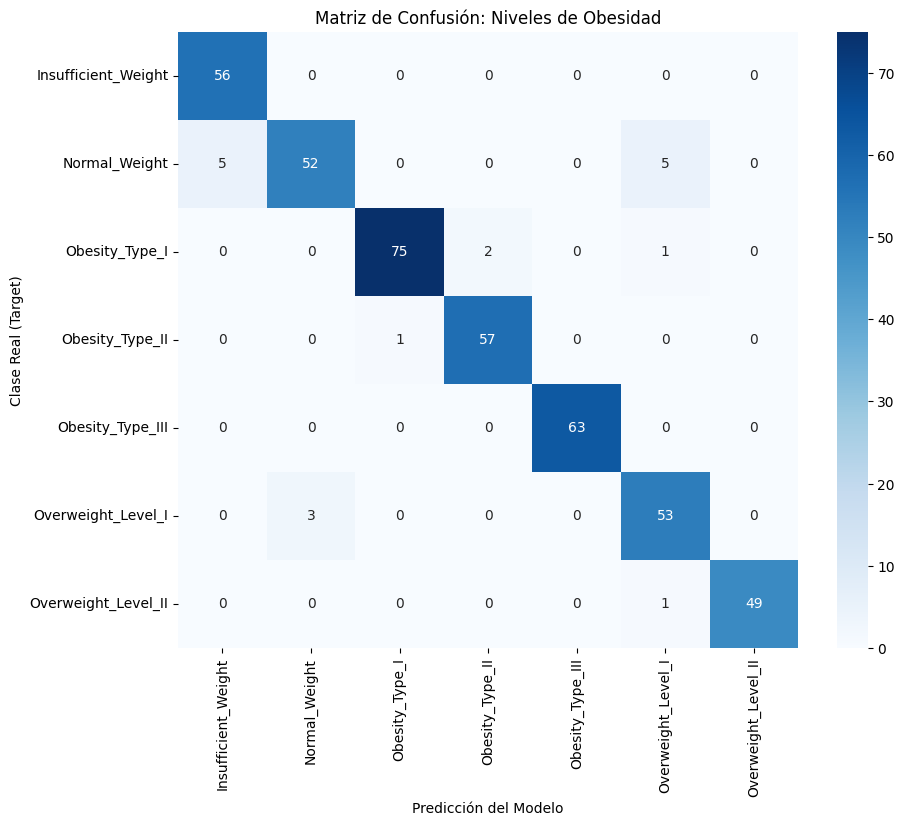

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calculamos la matriz con los datos de prueba
cm = confusion_matrix(y_test_encoded, y_test_pred)

# 2. Obtenemos los nombres de las categorías en orden (0, 1, 2...)
# Usamos el label encoder que guardamos antes
nombres_clases = le.classes_

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Target)')
plt.title('Matriz de Confusión: Niveles de Obesidad')
plt.show()

## Curva ROC

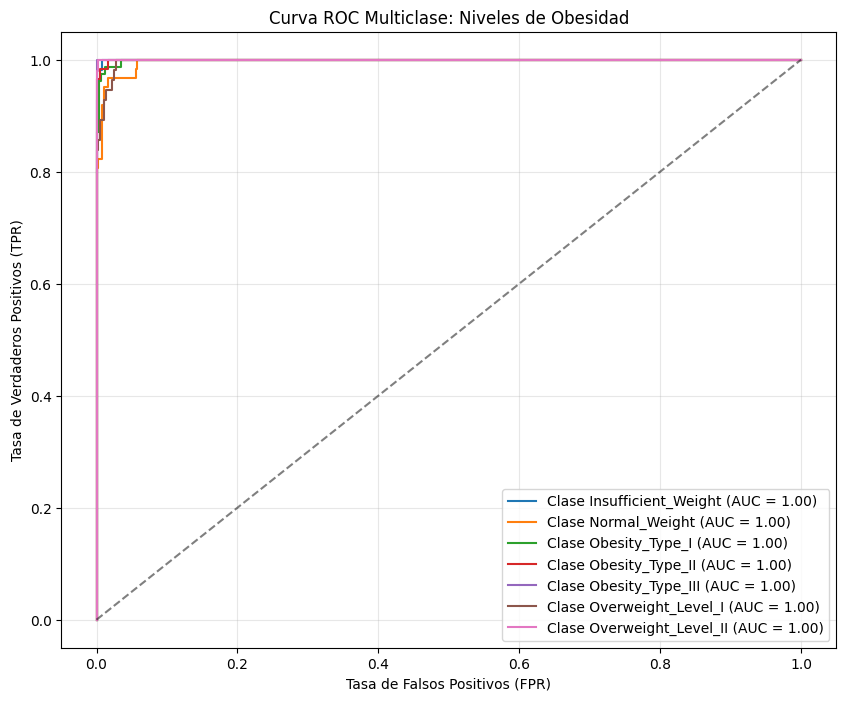

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculamos las probabilidades (necesarias para ROC)
y_probs = grid_search.predict_proba(X_test)

# 2. Configuramos el gráfico
plt.figure(figsize=(10, 8))

# Dibujamos una curva para cada una de las 7 clases
for i in range(len(le.classes_)):
    # Binarizamos para la clase actual: 1 si es la clase i, 0 si no lo es
    y_true_binary = (y_test_encoded == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'Clase {le.classes_[i]} (AUC = {roc_auc:.2f})')

# Línea de referencia (azar)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Multiclase: Niveles de Obesidad')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Generamos función para ver como funciona mi modelo

In [19]:
import pandas as pd

def predecir_obesidad(datos_nuevos_dict):
    """
    Recibe un diccionario con los datos de una persona,
    aplica el pipeline y devuelve la categoría real.
    """
    # Convertimos el diccionario a un DataFrame de una sola fila
    df_nuevo = pd.DataFrame([datos_nuevos_dict])
    
    # 1. El pipeline hace el preprocesamiento y la predicción (devuelve un número)
    prediccion_numerica = grid_search.predict(df_nuevo)
    
    # 2. El LabelEncoder transforma el número de vuelta a texto (ej: 'Obesity_Type_I')
    categoria_final = le.inverse_transform(prediccion_numerica)
    
    return categoria_final[0]

# --- PRUEBA DE LA FUNCIÓN ---
# Inventamos un paciente 
paciente_ejemplo = {
    'Age': 28,
    'Height': 1.75,
    'Weight': 84.0,
    'FCVC': 2.0,
    'NCP': 3.0,
    'CH2O': 2.0,
    'FAF': 1.0,
    'TUE': 0.0,
    'Gender': 'Male',
    'family_history_with_overweight': 'yes',
    'FAVC': 'yes',
    'CAEC': 'Sometimes',
    'CALC': 'Sometimes'
}

resultado = predecir_obesidad(paciente_ejemplo)
print(f"La predicción para el nuevo paciente es: {resultado}")

La predicción para el nuevo paciente es: Overweight_Level_II


## Guardamos el modelo

In [20]:
import joblib
import os

folder_path = os.path.join('..', 'models')

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Carpeta '{folder_path}' creada (no existía).")
else:
    print(f" La carpeta '{folder_path}' ya existe, guardando allí...")
    

modelo_final = grid_search.best_estimator_ 

# 2. Creamos el paquete completo (Modelo + LabelEncoder)
data_export = {
    'pipeline': modelo_final,
    'label_encoder': le,
    'columnas': list(X_train.columns) # Guardamos los nombres de las columnas por si acaso
}

# 3. Guardamos en el disco
joblib.dump(data_export, os.path.join(folder_path, 'modelo_obesidad-jm.pkl'))

print(" ¡Todo listo! El archivo 'modelo_obesidad_jm se guardo correctamente")


 La carpeta '..\models' ya existe, guardando allí...
 ¡Todo listo! El archivo 'modelo_obesidad_jm se guardo correctamente


##### Guardamos los datos de prueba para usarlos en el informe de evaluación

In [21]:
# Guardamos los datos de prueba para usarlos en el informe de evaluación
import os

# Creamos la carpeta de datos si no existe
folder_data = '../data/processed/'
if not os.path.exists(folder_data):
    os.makedirs(folder_data)

# Guardamos X_test e y_test_encoded
X_test.to_csv(os.path.join(folder_data, 'X_test_jm.csv'), index=False)
pd.DataFrame(y_test_encoded, columns=['Target']).to_csv(os.path.join(folder_data, 'y_test_jm.csv'), index=False)

print(" Datos listos en data/processed/ para el siguiente notebook.")

 Datos listos en data/processed/ para el siguiente notebook.


In [22]:
# 1. Obtenemos las predicciones del mejor modelo encontrado
y_pred_v2 = grid_search.best_estimator_.predict(X_test)

# 2. Creamos un DataFrame para cruzar datos
# Usamos X_test.copy() para tener todas las características (incluyendo gender)
analisis_v2 = X_test.copy()
analisis_v2['Real'] = y_test.values
analisis_v2['Prediccion'] = y_pred_v2

# 3. Filtramos solo los registros donde el modelo falló
errores_v2 = analisis_v2[analisis_v2['Real'] != analisis_v2['Prediccion']]

# 4. Mostramos los errores ordenados por el Weight más alto
cols_ver = ['Gender', 'Weight', 'Height', 'Real', 'Prediccion']
errores_v2[cols_ver].sort_values(by='Weight', ascending=False).head(10)
#errores_v2[cols_ver].sample(10)

,Gender,Weight,Height,Real,Prediccion
1910,Female,160.639405,1.803677,Obesity_Type_III,4
2029,Female,153.149491,1.805803,Obesity_Type_III,4
1826,Female,152.720545,1.827730,Obesity_Type_III,4
2030,Female,152.473675,1.796538,Obesity_Type_III,4
1949,Female,152.435630,1.792833,Obesity_Type_III,4
1950,Female,152.217135,1.810427,Obesity_Type_III,4
1814,Female,152.094362,1.730113,Obesity_Type_III,4
1877,Female,144.302261,1.746516,Obesity_Type_III,4
2076,Female,142.559161,1.817917,Obesity_Type_III,4
1972,Female,140.292018,1.808765,Obesity_Type_III,4


In [23]:
# 1. Traducimos los números de la predicción a nombres de categorías
# Usamos el label_encoder que ya tienes en el notebook
nombres_predichos = le.inverse_transform(errores_v2['Prediccion'])

# 2. Actualizamos el DataFrame de errores con los nombres
errores_v2_limpio = errores_v2.copy()
errores_v2_limpio['Prediccion'] = nombres_predichos

# 3. Ahora filtramos de nuevo: solo lo que REALMENTE sea distinto
errores_reales = errores_v2_limpio[errores_v2_limpio['Real'] != errores_v2_limpio['Prediccion']]

print(f" Número real de errores tras unificar formato: {len(errores_reales)}")

# 4. Miramos los casos más pesados
cols_mostrar = ['Gender', 'Weight', 'Height', 'Real', 'Prediccion']
errores_reales[cols_mostrar].sort_values(by='Weight', ascending=False).head(10)

 Número real de errores tras unificar formato: 18


,Gender,Weight,Height,Real,Prediccion
210,Male,114.000000,1.800000,Obesity_Type_II,Obesity_Type_I
1360,Male,109.599453,1.789421,Obesity_Type_I,Obesity_Type_II
1359,Male,109.411622,1.814052,Obesity_Type_I,Obesity_Type_II
408,Male,79.000000,1.810000,Normal_Weight,Overweight_Level_I
32,Female,76.000000,1.770000,Normal_Weight,Overweight_Level_I
387,Female,75.000000,1.500000,Obesity_Type_I,Overweight_Level_I
486,Male,75.000000,1.750000,Normal_Weight,Overweight_Level_I
1043,Female,74.433362,1.625236,Overweight_Level_II,Overweight_Level_I
65,Female,69.000000,1.620000,Overweight_Level_I,Normal_Weight
231,Female,66.000000,1.630000,Normal_Weight,Overweight_Level_I
